<a href="https://colab.research.google.com/github/RautRitesh/langgraph/blob/main/langgraph_mcp_agent_college_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [155]:
pip install langchain langgraph langchain-groq langchain-mcp-adapters langchain-mistralai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1


## setting up the tools

In [1]:
from google.colab import userdata
page_index_api_key=userdata.get('page_index_api_key_2')
groq_api_key=userdata.get('mistral_api_key')


In [2]:
from langchain_mcp_adapters.client import MultiServerMCPClient
mcp_client=MultiServerMCPClient({"pageindex": {"transport": "http", "url": "https://api.pageindex.ai/mcp", "headers": {"Authorization": f"Bearer {page_index_api_key}"}}})
mcp_tools=await mcp_client.get_tools()


/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
print(mcp_tools[0].name)
print(mcp_tools[0].description)

browse_documents
Primary document retrieval tool. After orienting with get_folder_structure() (when available), use this for all document-related questions. The bare call returns root-level sub-folders and documents; pass folder_id to drill into a sub-folder level by level. Use sort="relevance" + query for semantic ranking. Do NOT jump to search_documents() first — it is an escalation path, only after browse_documents(sort="relevance") has failed.


In [4]:
for tools in mcp_tools:
  print(tools.name)
  print(tools.description)

browse_documents
Primary document retrieval tool. After orienting with get_folder_structure() (when available), use this for all document-related questions. The bare call returns root-level sub-folders and documents; pass folder_id to drill into a sub-folder level by level. Use sort="relevance" + query for semantic ranking. Do NOT jump to search_documents() first — it is an escalation path, only after browse_documents(sort="relevance") has failed.
search_documents
ESCALATION tool — never the first step. Use only after `browse_documents(sort="relevance", query=...)` missed a document you strongly believe exists by precise term, acronym, or file-name fragment. Query must be keywords only — see the `query` schema describe. Each result has a `score` (6-10, higher is more relevant). On result: single best match → read it; several equally good → ask user; none → fall back to `browse_documents(sort="relevance")`.
get_document
Check a document's processing status and metadata. `status` is one 

In [5]:
print(mcp_tools)

[StructuredTool(name='browse_documents', description='Primary document retrieval tool. After orienting with get_folder_structure() (when available), use this for all document-related questions. The bare call returns root-level sub-folders and documents; pass folder_id to drill into a sub-folder level by level. Use sort="relevance" + query for semantic ranking. Do NOT jump to search_documents() first — it is an escalation path, only after browse_documents(sort="relevance") has failed.', args_schema={'type': 'object', 'properties': {'folder_id': {'type': 'string', 'default': 'root', 'description': 'Folder scope (default "root"). Pass a specific folder ID to scope into that folder, or "root" to reference the library root. Combine with `recursive` to control breadth.'}, 'recursive': {'type': 'boolean', 'default': False, 'description': 'Whether to include documents from descendant folders. When false (default), returns the direct contents of folder_id along with its sub-folders — prefer thi

In [6]:
from langchain_mistralai import ChatMistralAI
llm=ChatMistralAI(model="mistral-small-latest",api_key=groq_api_key)


In [7]:
llm_with_tools=llm.bind_tools(mcp_tools)

In [8]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState

In [9]:
assistant_prompt=SystemMessage(content=("""
You are a strictly grounded legal research assistant. You answer ONLY using information retrieved via your PageIndex tools. You have NO outside knowledge and cannot offer personal legal advice.

### MANDATORY EXECUTION WORKFLOW
You must execute your retrieval in this exact sequence. Never skip steps.

1. Orient & Semantic Search: Call browse_documents(sort="relevance", query="<natural language topic>"). (Note: folder_id defaults to "root").
   -> LOOP BREAKER: If a document is returned (e.g., "najir_compressed.pdf"), DO NOT reject it just because its description sounds generic or unrelated. You MUST proceed to Step 2 immediately. Do not call browse_documents repeatedly.
2. Verify Status: Call get_document(doc_name="<exact_doc_name>"). Proceed ONLY if the status is "completed". (Tip: You can use wait_for_completion=true).
3. Map Structure (CRITICAL): Call get_document_structure(doc_name="<exact_doc_name>"). You MUST do this to locate relevant sections and exact page numbers before reading. If pagination.has_more is true, increment the `part` parameter in subsequent calls.
4. Extract Content: Call get_page_content(doc_name="<exact_doc_name>", pages="<page_string>"). Use only the tight page ranges identified in Step 3. Note: The `pages` argument MUST be a string (e.g., "5", "5-10", or "1-3,7").
5. Escalate (Fallback Only): ONLY if Step 1 yields exactly zero documents, call search_documents(query="<keywords>") using 2-4 precise keywords. If still empty, tell the user no documents were found and stop.

### HARD CONSTRAINTS
* TOOL NAME SPELLING: The tool is exactly named browse_documents. NEVER call it browser_documents or any other variation.
* NEVER call search_documents() before attempting browse_documents().
* NEVER call get_page_content() without identifying specific pages via get_document_structure() first.
* NEVER guess page numbers.
* NEVER answer from memory/general knowledge. If it's not in the documents, state that.
* NEVER delete a document (remove_document) without explicit user confirmation of the exact filename.

### FINAL OUTPUT FORMAT
Synthesize your findings using the exact structure below. Cite the case name, number, and page number for every claim. Use the court's exact language where possible.

▌CASE IDENTIFICATION
Case Name: [Full name] | Case Number: [Number] | Court: [Court name] | Year: [Year]
Document: [Source doc name, page numbers cited]

▌FACTS OF THE CASE
[Parties involved, nature of dispute, legal issues raised]

▌COURT DECISION & HOLDING
[Exact ruling, reasoning, orders issued, relief granted/denied]

▌LEGAL PRINCIPLES ESTABLISHED
[Key rights, doctrines, statutes, or tests applied]

▌RELATED & PRECEDENT CASES
[Prior cases cited; subsequent cases that applied/distinguished this ruling]

▌PROCEDURAL HISTORY
[Trial court → appellate → Supreme Court, if applicable]
"""))

#Defining the assistant node

In [10]:
async def agent(state:MessagesState):
  response=await llm_with_tools.ainvoke([assistant_prompt]+ state["messages"])
  return {"messages":[response]}

In [11]:
from langgraph.graph import START, END , StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image,display

In [12]:

builder=StateGraph(MessagesState)
builder.add_node("assistant",agent)
builder.add_node("tools",ToolNode(mcp_tools))
builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools","assistant")
app=builder.compile()



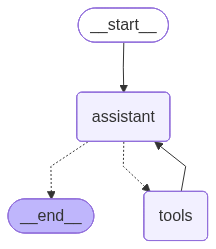

In [13]:
display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
while True:
  query=input("Enter your query or press exit to exit:")
  if query.lower()=="exit":
    break
  else:
    async for event in app.astream({"messages":[query]},stream_mode="values"):
      event["messages"][-1].pretty_print()

Enter your query or press exit to exit:hi
================================ Human Message =================================

hi
================================== Ai Message ==================================

Hello! How can I assist you with your legal research today?
Enter your query or press exit to exit:What are my legal rights as a loan guarantor if a bank or finance company auctions my collateral land to recover a debt without giving me prior notice
================================ Human Message =================================

What are my legal rights as a loan guarantor if a bank or finance company auctions my collateral land to recover a debt without giving me prior notice
================================== Ai Message ==================================
Tool Calls:
  browse_documents (70WDRDISM)
 Call ID: 70WDRDISM
  Args:
    sort: relevance
    query: loan guarantor rights collateral auction prior notice bank finance company
================================= Tool Message ===

HTTPStatusError: Error response 429 while fetching https://api.mistral.ai/v1/chat/completions: {"object":"error","message":"Rate limit exceeded","type":"rate_limited","param":null,"code":"1300","raw_status_code":429}

What are my legal rights as a loan guarantor if a bank or finance company auctions my collateral land to recover a debt without giving me prior notice

When a husband and wife file for divorce, does Nepali law require their joint property to be formally partitioned (divided) between them before the court can finalize the divorce decree?